In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 1 — EDA (Titanic)

In [3]:
df.shape

(891, 12)

In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [8]:
df.describe(include = "all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [9]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', 
                                                                                    ascending = False)
missing_summary

,missing_count,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


In [11]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [13]:
df['Survived'].value_counts(normalize = True).round(3) * 100

Survived
0    61.6
1    38.4
Name: proportion, dtype: float64

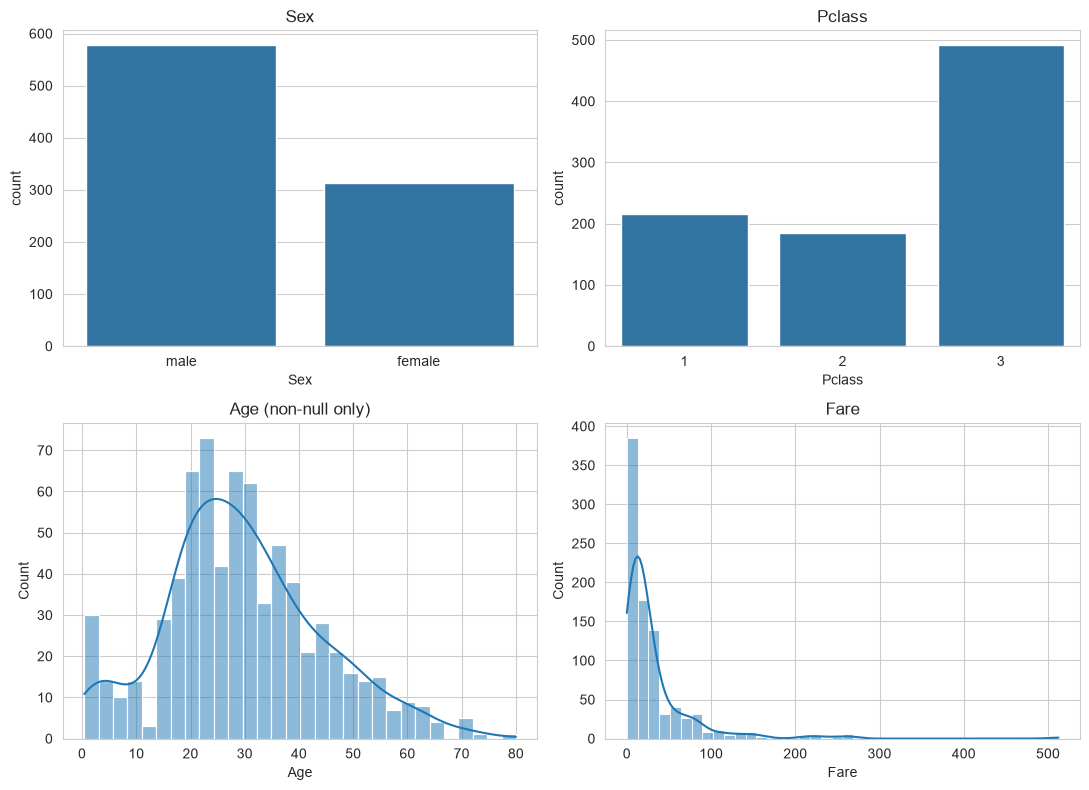

In [16]:
fig, axes = plt.subplots(2, 2, figsize = (11, 8))

sns.countplot(data = df, x = 'Sex', ax = axes[0, 0])
axes[0, 0].set_title('Sex')

sns.countplot(data = df, x = 'Pclass', ax = axes[0, 1])
axes[0, 1].set_title('Pclass')

sns.histplot(df['Age'].dropna(), bins = 30, ax = axes[1, 0], kde = True)
axes[1, 0].set_title('Age (non-null only)')

sns.histplot(df['Fare'], bins = 40, ax = axes[1, 1], kde = True)
axes[1, 1].set_title('Fare')

plt.tight_layout()
plt.show()

C:\Users\zahin\AppData\Local\Temp\ipykernel_5356\462518247.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 1].set_xticklabels(['Died', 'Survived'])


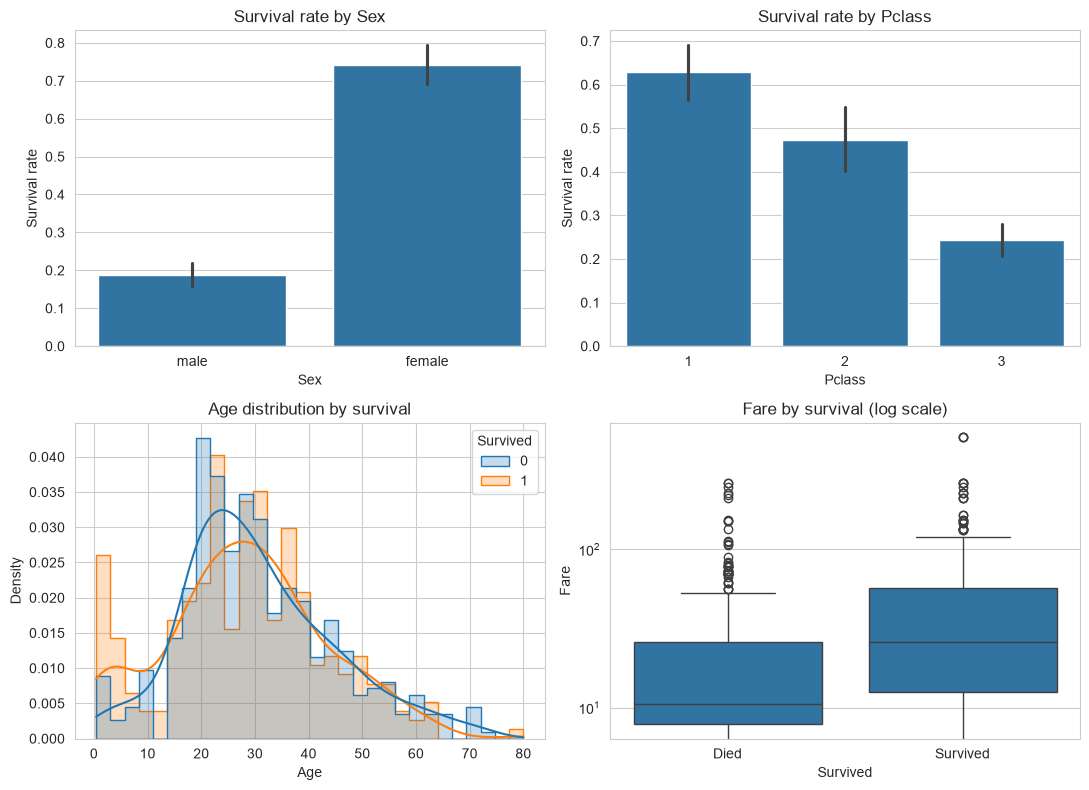

In [17]:
fig, axes = plt.subplots(2, 2, figsize = (11, 8))

sns.barplot(data = df, x = 'Sex', y = 'Survived', ax = axes[0, 0])
axes[0, 0].set_title('Survival rate by Sex')
axes[0, 0].set_ylabel('Survival rate')

sns.barplot(data = df, x = 'Pclass', y = 'Survived', ax = axes[0, 1])
axes[0, 1].set_title('Survival rate by Pclass')
axes[0, 1].set_ylabel('Survival rate')

sns.histplot(data = df, x = 'Age', hue = 'Survived', bins = 30, kde = True,
             element = 'step', stat = 'density', common_norm = False, ax = axes[1, 0])
axes[1, 0].set_title('Age distribution by survival')

sns.boxplot(data = df, x = 'Survived', y = 'Fare', ax = axes[1, 1])
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Fare by survival (log scale)')
axes[1, 1].set_xticklabels(['Died', 'Survived'])

plt.tight_layout()
plt.show()